
# Ημέρα 2 — Overfitting, Regularization & Threshold Tuning (Recall ≥ 0.90)

**Week 3 · cc-fraud-detection**  
**Στόχος:** Επιλογή έντασης L2 regularization (hyperparameter **C**) σε Logistic Regression και **threshold tuning** για **Recall ≥ 0.90** (ή άλλο επιχειρησιακό στόχο).  
**Συγγραφέας:** Lazaros Voulistiotis  
**Ημερομηνία δημιουργίας notebook:** 2025-09-14 17:33

---

### Τι θα κάνεις
- Φόρτωση dataset & στόχου (binary: 0/1)
- Grid σε **C ∈ {0.01, 0.1, 1, 10}**
- Αξιολόγηση σε **threshold=0.5** (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
- Επιλογή **καλύτερου C** βάσει **PR-AUC (Average Precision)**
- **Threshold tuning** για να πετύχεις **Recall ≥ 0.90**
- Αποθήκευση γραφημάτων: ROC/PR ανά C, PR στο best C με σημείο threshold, και Confusion Matrix στο επιλεγμένο threshold

> 💡 **Συμβουλή:** Σε εντονό **class imbalance** προτίμησε PR-AUC για επιλογή μοντέλου και χρησιμοποίησε **class_weight="balanced"**.


In [38]:

# ---- ΒΙΒΛΙΟΘΗΚΕΣ ----
import numpy as np               # αριθμητικοί πίνακες, μαθηματικές πράξεις
import pandas as pd              # dataframes, φόρτωση/επεξεργασία δεδομένων
import matplotlib.pyplot as plt  # γραφήματα, visualization

# --- scikit-learn modules ---
from sklearn.model_selection import train_test_split
# Χωρίζει dataset σε train/test (με stratify, random_state κλπ.)

from sklearn.preprocessing import StandardScaler
# Standardization (μέσος όρος=0, std=1) — απαραίτητο για Logistic Regression με L2 regularization

from sklearn.pipeline import Pipeline
# Επιτρέπει να φτιάξεις ένα pipeline: π.χ. StandardScaler -> LogisticRegression

from sklearn.linear_model import LogisticRegression
# Ο classifier μας: Logistic Regression με παραμέτρους (C, penalty, class_weight κ.λπ.)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
# Accuracy = ποσοστό σωστών προβλέψεων
# Precision = από όλα τα "fraud" που βρήκε, πόσα ήταν όντως fraud
# Recall = από όλα τα πραγματικά fraud, πόσα βρήκε
# F1 = ισορροπία Precision/Recall
# ROC-AUC = συνολική ικανότητα διάκρισης (0.5=τυχαίο, 1=τέλειο)
# Average Precision (PR-AUC) = area κάτω από Precision–Recall curve (σημαντικό σε imbalanced data)
# roc_curve, precision_recall_curve = για καμπύλες thresholds
# confusion_matrix = πίνακας σφαλμάτων (TP, FP, FN, TN)
# classification_report = summary με precision, recall, f1 ανά κλάση

In [60]:
# ================== ΡΥΘΜΙΣΕΙΣ ==================
from pathlib import Path

# 📂 Dataset path (cross-platform με Pathlib)
# Αλλάζεις ΜΟΝΟ αυτό αν το dataset μπει σε άλλο φάκελο/όνομα
DATA_PATH = Path("../../data/data_raw/creditcard.csv")

# 🎯 Υποψήφιες στήλες για target (binary labels 0/1)
TARGET_CANDIDATES = ["Class", "class", "is_fraud"]

# ⚙️ Logistic Regression — υπερπαράμετρος C
# - μικρό C → ισχυρότερη regularization
# - μεγάλο C → πιο χαλαρή regularization
# Grid values σε λογαριθμική κλίμακα
CS = [0.01, 0.1, 1, 10]

# 📊 Train/Test split
TEST_SIZE = 0.30       # 30% test, 70% train
RANDOM_STATE = 42      # reproducibility (ίδιο split σε κάθε run)

# 🚨 Recall target για threshold tuning
# Θέλουμε Recall >= RECALL_TARGET (να πιάσουμε τις περισσότερες απάτες)
# αλλά θα θυσιάσουμε Precision (περισσότερα false positives).
RECALL_TARGET = 0.90

# 📁 Διαδρομές για reports & figures (ώστε όλα τα outputs να πάνε σε σταθερά σημεία)
REPORTS_DIR = Path("../../reports/week3_metrics")
FIGURES_DIR = Path("../../reports/figures/week3")

# Δημιουργία φακέλων αν δεν υπάρχουν
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Ρυθμίσεις φορτώθηκαν. Dataset: {DATA_PATH}, Reports: {REPORTS_DIR}, Figures: {FIGURES_DIR}")


✅ Ρυθμίσεις φορτώθηκαν. Dataset: ..\..\data\data_raw\creditcard.csv, Reports: ..\..\reports\week3_metrics, Figures: ..\..\reports\figures\week3


In [50]:

# ---- HELPERS ----

def find_target(df, candidates):
    """
    Βρίσκει τη στήλη-στόχο (binary labels) σε ένα DataFrame.
    Args:
        df (pd.DataFrame): Το dataset.
        candidates (list of str): Λίστα πιθανών ονομάτων στηλών-στόχου
                                  (π.χ. ["Class", "class", "is_fraud"]).
    Returns:
        str: Το όνομα της στήλης-στόχου που βρέθηκε.
    Raises:
        ValueError: Αν δεν βρεθεί καμία στήλη από τις υποψήφιες.
    """
    for c in candidates:
        if c in df.columns:
            # Τσεκάρουμε αν τα values είναι binary (0/1)
            unique_vals = set(df[c].dropna().unique())
            if not unique_vals.issubset({0, 1}):
                print(f"⚠️ Προειδοποίηση: Η στήλη '{c}' δεν είναι καθαρά binary (values={unique_vals})")
            return c
    
    raise ValueError(
        f"❌ Δεν βρέθηκε καμία στήλη-στόχος.\n"
        f"➡ Δοκιμάστηκαν: {candidates}\n"
        f"📋 Διαθέσιμες στήλες: {list(df.columns)}"
    )

- Σκοπός: βρίσκει ποια στήλη του DataFrame είναι το target (0/1).
- Λογική: ψάχνει μέσα στις πιθανές (candidates = π.χ. ["Class", "class", "is_fraud"]) και επιστρέφει την πρώτη που βρει.
- Fail case: αν δεν βρει καμία, σηκώνει ValueError με κατανοητό μήνυμα.
💡 Καλή πρακτική γιατί datasets μπορεί να έχουν διαφορετικά ονόματα στηλών.

In [51]:
def ensure_outdir():
    """
    Δημιουργεί (αν δεν υπάρχει ήδη) τον φάκελο εξόδου για τα γραφήματα.
    Επιστρέφει:
        Path: Το αντικείμενο Path που δείχνει στον φάκελο 'images/week3'.
    """
    out = Path("../../reports/figures/week3")                 # Ο φάκελος όπου θα αποθηκευτούν όλα τα plots
    out.mkdir(parents=True, exist_ok=True)     # Δημιούργησε τον φάκελο και τους γονικούς (αν χρειάζεται)
                                               # exist_ok=True: δεν πετάει error αν υπάρχει ήδη
    return out                                 # Επιστροφή του Path ώστε να χρησιμοποιηθεί σε plt.savefig()


In [52]:
def print_metrics_table(rows, title="Metrics per C"):
    """
    Εμφανίζει έναν πίνακα με τις μετρικές από το πείραμα Logistic Regression.
    Χρησιμοποιεί Styler API (pandas >= 1.4).
    """
    dfm = pd.DataFrame(rows)
    display(dfm.style.hide(axis="index").set_caption(title))


In [53]:
def choose_threshold_by_recall(y_true, proba, recall_target=0.90):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    candidates = []
    for i in range(len(thresholds)):
        r = recall[i]
        p = precision[i]
        thr = thresholds[i]
        if r >= recall_target:
            candidates.append((thr, p, r))
# Σκοπός: βρίσκει το μικρότερο threshold που πιάνει recall ≥ στόχο.
# precision_recall_curve επιστρέφει τριπλέτα (precision, recall, thresholds).
# Για κάθε threshold, κρατάς precision, recall, threshold.
# Αν το recall στο συγκεκριμένο threshold ≥ στόχος (π.χ. 0.90), τον βάζεις στους υποψήφιους (candidates).
    if not candidates:
        best_i = int(np.argmax(recall))
        best_thr = thresholds[min(best_i, len(thresholds)-1)] if len(thresholds) > 0 else 0.5
        return best_thr, float(precision[best_i]), float(recall[best_i])
# Case: Αν δεν υπάρχει threshold που να πιάνει recall ≥ στόχο.
# Τότε παίρνεις το μέγιστο recall διαθέσιμο (np.argmax(recall)).
# Αν δεν υπάρχουν thresholds (empty case), κάνεις fallback σε 0.5.
# Επιστρέφεις (threshold, precision, recall) του καλύτερου σημείου που κατάφερες να βρεις.

    # Αν υπάρχουν υποψήφιοι thresholds
    best_thr, best_p, best_r = max(candidates, key=lambda x: (x[1], -x[0]))
    return float(best_thr), float(best_p), float(best_r)
#Από τους υποψήφιους, διαλέγεις αυτόν με το υψηλότερο precision (για να περιορίσεις τα false positives), και αν υπάρχει ισοβαθμία, προτιμάς το μικρότερο threshold.
# Επιστρέφεις threshold, precision, recall ως floats (για καθαρό formatting).


🔑 Τι κάνει συνολικά αυτό το block

- find_target → ποια είναι η στήλη στόχος
- ensure_outdir → βεβαιώσου ότι υπάρχει φάκελος εικόνων
- print_metrics_table → εμφάνισε metrics σε Jupyter-friendly πίνακα
- choose_threshold_by_recall → διάλεξε threshold που πετυχαίνει recall ≥ στόχος με το καλύτερο δυνατό precision


## 2) Φόρτωση Dataset
- Αντί για `creditcard.csv` μπορείς να ορίσεις άλλο αρχείο/μονοπάτι.  
- Το target πρέπει να είναι μία στήλη **0/1** με όνομα ένα από: `Class`, `class`, `is_fraud` (ή άλλαξε το helper).


In [54]:
# ---- ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ----

# 1) Έλεγχος ύπαρξης dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"❌ Missing {DATA_PATH}. Put the dataset in data/data_raw/")

# 2) Φάκελος για αποθήκευση outputs (π.χ. plots)
outdir = ensure_outdir()

# 3) Φόρτωμα CSV σε DataFrame
df = pd.read_csv(DATA_PATH)

# 4) Εντοπισμός target column (π.χ. "Class")
y_col = find_target(df, TARGET_CANDIDATES)

# 5) Αφαίρεση διπλοτύπων (προληπτικά)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
removed = before - len(df)
if removed > 0:
    print(f"ℹ️ Αφαιρέθηκαν {removed} διπλότυπες γραμμές.")

# 6) Ορισμός y (target) & X (features μόνο numeric)
y = df[y_col].astype(int)
X = df.drop(columns=[y_col]).select_dtypes(include=[np.number])

# 7) Εκτυπώσεις ελέγχου
print(f"✅ Dataset loaded: shape={df.shape}")
print(f"   Target column: {y_col}")
print(f"   Fraud rate: {y.mean():.6f} (~{y.mean()*100:.3f}%)")
print(f"   Features used: {X.shape[1]} numeric columns")

# 8) Preview
display(df.head(3))


ℹ️ Αφαιρέθηκαν 1081 διπλότυπες γραμμές.
✅ Dataset loaded: shape=(283726, 31)
   Target column: Class
   Fraud rate: 0.001667 (~0.167%)
   Features used: 30 numeric columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [55]:
# ---- SPLIT ----
# Διαχωρισμός σε training και test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Συγκεντρώνουμε τα αποτελέσματα σε DataFrame για να είναι πιο ευανάγνωστα
split_check = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "fraud_rate": [y_train.mean(), y_test.mean()]
}, index=["train", "test"])

# Μορφοποίηση fraud_rate σε ποσοστό
split_check["fraud_rate (%)"] = (split_check["fraud_rate"] * 100).round(4)

print(f"✅ Split done: Train={len(X_train)}, Test={len(X_test)}")
display(split_check)


✅ Split done: Train=198608, Test=85118


,rows,fraud_rate,fraud_rate (%)
train,198608,0.001667,0.1667
test,85118,0.001668,0.1668



## 3) Grid σε C & Αξιολόγηση @ threshold=0.5

- Για κάθε C φτιάχνουμε Pipeline: **StandardScaler → LogisticRegression(L2, class_weight="balanced")**  
- Υπολογίζουμε metrics στο **0.5** και γράφουμε **ROC/PR** καμπύλες σε `reports/figures/week3`.


«Grid σε C» σημαίνει ότι δοκιμάζουμε πολλαπλές τιμές της υπερπαραμέτρου C στη Logistic Regression, για να βρούμε ποια δίνει την καλύτερη απόδοση (με βάση τη μετρική που μας νοιάζει, π.χ. PR-AUC). Είναι ένα grid search αλλά μόνο πάνω στην παράμετρο C.

Τι είναι το C στη Logistic Regression;
- Η Logistic με penalty='l2' (default) λύνει μια βελτιστοποίηση που τιμωρεί μεγάλα βάρη.
- Το C είναι ο αντίστροφος της έντασης κανονικοποίησης (regularization strength):
    - Μικρό C → Ισχυρή κανονικοποίηση → τα βάρη «μαζεύουν» (πιο ομαλό/απλό μοντέλο) → λιγότερο overfitting, αλλά κινδυνεύει από underfitting.
    - Μεγάλο C → Αδύναμη κανονικοποίηση → τα βάρη μπορούν να «φουσκώσουν» για να ταιριάξουν καλύτερα τα δεδομένα → λιγότερο bias, αλλά κίνδυνος overfitting.
- Ισοδύναμα, αν θες να σκέφτεσαι με λήμματα: συχνά βλέπεις όρο λήμματος λ όπου λ = 1/C. Άρα μικρό C = μεγάλο λ (πολύ regularization).

Γιατί κάνουμε grid σε C;
- Γιατί το «σωστό» επίπεδο regularization εξαρτάται από τα δεδομένα.
- Δοκιμάζουμε τυπικά λογαριθμική σκάλα τιμών (π.χ. 0.001, 0.01, 0.1, 1, 10, 100) και κρατάμε αυτή που μεγιστοποιεί τη μετρική-στόχο:
    - Σε imbalanced προβλήματα (fraud), προτείνεται PR-AUC (Average Precision) ή/και Recall σε ενδιαφέρον threshold.
    - ROC-AUC είναι χρήσιμο, αλλά το PR-AUC συνήθως λέει περισσότερα όταν το θετικό είναι σπάνιο.

Πώς το κάνουμε σωστά
- Pipeline: StandardScaler() → LogisticRegression(class_weight="balanced") για να:
    - κλιμακώσεις features (απαραίτητο σε γραμμικά μοντέλα με regularization),
    - ζυγίσεις τη σπάνια κλάση (balanced).
- Στρατηγική αξιολόγησης:
    - Απλό split (train/valid ή train/test), ή
    - Stratified k-fold cross-validation για πιο σταθερά αποτελέσματα.
- Επιλογή solver: lbfgs είναι καλός για L2. Για L1 θέλεις liblinear ή saga.
- Κλίμακα τιμών: ξεκίνα με np.logspace(-3, 2, 6) → 0.001..100 και στένεψε γύρω από το καλύτερο.

Διαισθητικά τι αλλάζει όταν αλλάζω C;
- Μικρό C: τα coefficients μικραίνουν, τα decision boundaries γίνονται πιο «συντηρητικά». Συνήθως μικρό variance, πιθανό μεγαλύτερο bias.
- Μεγάλο C: το μοντέλο «κυνηγά» την εκπαίδευση πιο επιθετικά. Πιθανό overfitting, ειδικά αν έχεις πολλά/συγγραμμικά features.

In [59]:
# Συλλογή αποτελεσμάτων για report & επιλογή καλύτερου C 
rows = []
best_key = None
best_score = -np.inf
best_pipe = None
best_proba = None

# όπου θα σώσουμε συγκεντρωτικά τα plots/metrics
metrics_csv_path = REPORTS_DIR / "week3_day1_logreg_grid.csv"

for C in CS:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            penalty="l2",
            C=C,
            solver="lbfgs",
            random_state=RANDOM_STATE
        ))
    ])

    pipe.fit(X_train, y_train)

    # Probabilities & predictions @ 0.5 (baseline)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred_05 = (proba >= 0.5).astype(int)

    # Threshold-free metrics
    rocauc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    # Thresholded metrics @ 0.5
    acc  = accuracy_score(y_test, pred_05)
    prec = precision_score(y_test, pred_05, zero_division=0)
    rec  = recall_score(y_test, pred_05, zero_division=0)
    f1   = f1_score(y_test, pred_05, zero_division=0)

    # Confusion matrix @ 0.5 (για διαφάνεια στα FP/FN)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_05).ravel()
    n_pos_pred = int(pred_05.sum())

    rows.append({
        "C": C,
        "ROC-AUC": round(rocauc, 4),
        "PR-AUC(AP)": round(ap, 4),
        "Accuracy@0.5": round(acc, 4),
        "Precision@0.5": round(prec, 4),
        "Recall@0.5": round(rec, 4),
        "F1@0.5": round(f1, 4),
        "TP@0.5": tp, "FP@0.5": fp, "FN@0.5": fn, "TN@0.5": tn,
        "PositivesPred@0.5": n_pos_pred,
    })

    # --- ROC plot per C ---
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure(figsize=(5.2, 4.4))
    plt.plot(fpr, tpr, label=f"AUC={rocauc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (C={C})")
    plt.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"roc_C{C}.png", bbox_inches="tight")
    plt.close()

    # --- PR plot per C ---
    pr, rc, _ = precision_recall_curve(y_test, proba)
    plt.figure(figsize=(5.2, 4.4))
    plt.plot(rc, pr, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve (C={C})")
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"pr_C{C}.png", bbox_inches="tight")
    plt.close()

    # --- model selection by PR-AUC (AP) ---
    if ap > best_score:
        best_score = ap
        best_key = C
        best_pipe = pipe
        best_proba = proba  # θα το χρειαστούμε για threshold tuning

# Πίνακας μετρικών (όλες οι τιμές C)
df_grid = pd.DataFrame(rows).sort_values("PR-AUC(AP)", ascending=False)
display(df_grid.style.hide(axis="index").set_caption("LogReg L2 — Metrics per C (thr=0.5)"))

# Αποθήκευση σε CSV για report/traceability
df_grid.to_csv(metrics_csv_path, index=False)
print(f"📄 Saved grid metrics to: {metrics_csv_path}")

print(f"\n🏆 Best C by PR-AUC(AP): {best_key} (AP={best_score:.4f})")



C,ROC-AUC,PR-AUC(AP),Accuracy@0.5,Precision@0.5,Recall@0.5,F1@0.5,TP@0.5,FP@0.5,FN@0.5,TN@0.5,PositivesPred@0.5
10.000000,0.966400,0.688600,0.973200,0.052700,0.887300,0.099400,126,2267,16,82709,2393
1.000000,0.966300,0.687700,0.973200,0.052700,0.887300,0.099400,126,2267,16,82709,2393
0.100000,0.966200,0.682200,0.973400,0.053000,0.887300,0.100000,126,2251,16,82725,2377
0.010000,0.966100,0.672400,0.973700,0.053700,0.887300,0.101200,126,2222,16,82754,2348


📄 Saved grid metrics to: ..\..\reports\week3_metrics\week3_day1_logreg_grid.csv

🏆 Best C by PR-AUC(AP): 10 (AP=0.6886)



## 4) Threshold Tuning (στόχος: Recall ≥ 0.90)

- Επιλέγουμε **threshold** στο **best C** με συνθήκη `Recall ≥ RECALL_TARGET`.  
- Αναφέρουμε metrics στο νέο threshold & αποθηκεύουμε PR curve με σημείο threshold + Confusion Matrix.


Selected threshold = 0.2678
Metrics @thr: Acc=0.9365  Prec=0.0232  Rec=0.9014  F1=0.0452  ROC-AUC=0.9664  PR-AUC(AP)=0.6886  FPR=0.0635  Specificity=0.9365
Confusion matrix @thr=0.2678 (C=10):
[[79581  5395]
 [   14   128]]
TP=128  FP=5395  FN=14  TN=79581  | Predicted Positives=5523


C,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC(AP),FPR,Specificity,TP,FP,FN,TN,Predicted_Pos,Support_Pos,Support_Neg
10,0.267800,0.936500,0.023200,0.901400,0.045200,0.966400,0.688600,0.063500,0.936500,128,5395,14,79581,5523,142,84976


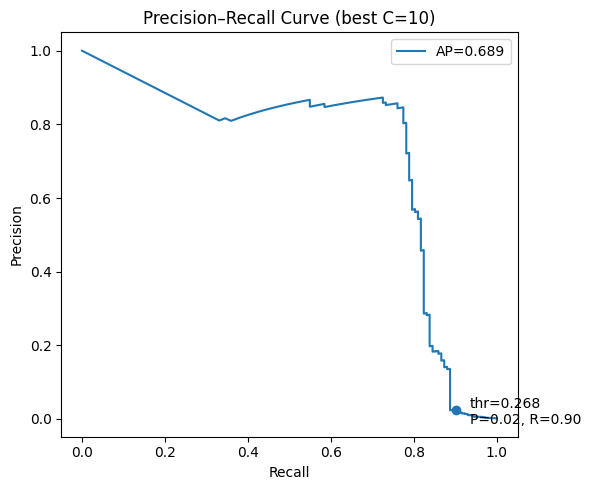

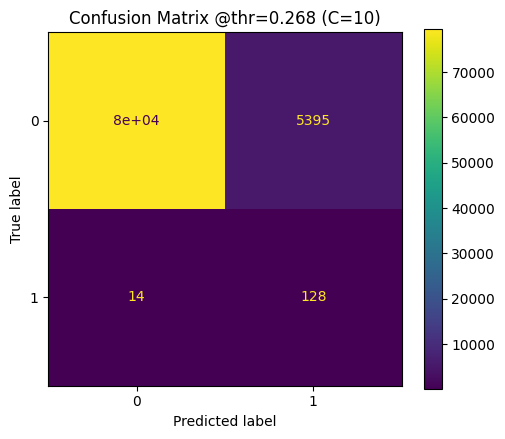

📄 Saved:
 - ..\..\reports\week3_metrics\week3_day2_threshold_selection.csv
 - ..\..\reports\week3_metrics\week3_day2_threshold_selection.json
 - ..\..\reports\figures\week3\pr_bestC10_thr0.268.png
 - ..\..\reports\figures\week3\cm_bestC10_thr0.268.png


In [58]:
# -------------------- Threshold tuning στο καλύτερο C (βελτιωμένο) --------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay
)
import json

# --- Safeguards ---
if best_key is None:
    raise RuntimeError("Δεν έχει επιλεγεί best C. Τρέξε πρώτα το grid loop για τα CS.")
if "proba_per_C" not in globals() or best_key not in proba_per_C:
    # Αν έχεις κρατήσει μόνο best_proba/best_pipe, χρησιμοποίησέ τα:
    proba_best = best_proba if "best_proba" in globals() else None
    if proba_best is None:
        raise RuntimeError("Λείπουν οι πιθανότητες για το καλύτερο C. Βεβαιώσου ότι αποθηκεύεις proba.")
else:
    proba_best = proba_per_C[best_key]

# Βρες threshold που πιάνει στόχο Recall (και όσο γίνεται καλύτερο Precision)
thr, p_at_thr, r_at_thr = choose_threshold_by_recall(
    y_test, proba_best, recall_target=RECALL_TARGET
)
pred_thr = (proba_best >= thr).astype(int)

# Μετρικές @thr
acc    = accuracy_score(y_test, pred_thr)
prec   = precision_score(y_test, pred_thr, zero_division=0)
rec    = recall_score(y_test, pred_thr, zero_division=0)
f1     = f1_score(y_test, pred_thr, zero_division=0)
rocauc = roc_auc_score(y_test, proba_best)           # threshold-free
ap     = average_precision_score(y_test, proba_best) # PR-AUC

# Confusion matrix & extra KPIs
cm = confusion_matrix(y_test, pred_thr)
tn, fp, fn, tp = cm.ravel()
n_pos_pred = int(pred_thr.sum())
support_pos = int((y_test == 1).sum())
support_neg = int((y_test == 0).sum())
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"Selected threshold = {thr:.4f}")
print(
    f"Metrics @thr: Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  "
    f"ROC-AUC={rocauc:.4f}  PR-AUC(AP)={ap:.4f}  FPR={fpr:.4f}  Specificity={specificity:.4f}"
)
print(f"Confusion matrix @thr={thr:.4f} (C={best_key}):\n{cm}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}  | Predicted Positives={n_pos_pred}")

# Πίνακας για report
thr_row = pd.DataFrame([{
    "C": best_key,
    "threshold": round(thr, 4),
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC-AUC": round(rocauc, 4),
    "PR-AUC(AP)": round(ap, 4),
    "FPR": round(fpr, 4),
    "Specificity": round(specificity, 4),
    "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    "Predicted_Pos": n_pos_pred,
    "Support_Pos": support_pos,
    "Support_Neg": support_neg
}])
display(thr_row.style.hide(axis="index").set_caption(f"Metrics @ threshold={thr:.4f} (best C={best_key})"))

# -------------------- Precision–Recall Curve με σημείωση threshold --------------------
pr, rc, thresholds = precision_recall_curve(y_test, proba_best)
fig_pr, ax_pr = plt.subplots(figsize=(6, 5))
ax_pr.plot(rc, pr, label=f"AP={ap:.3f}")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title(f"Precision–Recall Curve (best C={best_key})")
ax_pr.legend(loc="upper right", frameon=True)

# σημείο κοντινό στο επιλεγμένο threshold (αν υπάρχουν thresholds)
if len(thresholds) > 0:
    idx = int(np.argmin(np.abs(thresholds - thr)))
    ax_pr.scatter(rc[idx], pr[idx], marker="o")
    ax_pr.annotate(
        f"thr={thr:.3f}\nP={pr[idx]:.2f}, R={rc[idx]:.2f}",
        (rc[idx], pr[idx]), textcoords="offset points", xytext=(10, -10)
    )

fig_pr.tight_layout()
pr_marked_path = FIGURES_DIR / f"pr_bestC{best_key}_thr{thr:.3f}.png"
fig_pr.savefig(pr_marked_path, dpi=150, bbox_inches="tight")
plt.show()

# -------------------- Confusion Matrix (sklearn display) --------------------
fig_cm, ax_cm = plt.subplots(figsize=(5.2, 4.4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_thr, ax=ax_cm, colorbar=True)
ax_cm.set_title(f"Confusion Matrix @thr={thr:.3f} (C={best_key})")
fig_cm.tight_layout()
cm_path = FIGURES_DIR / f"cm_bestC{best_key}_thr{thr:.3f}.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

# -------------------- Save results for reproducibility --------------------
thr_csv_path = REPORTS_DIR / "week3_day2_threshold_selection.csv"
thr_json_path = REPORTS_DIR / "week3_day2_threshold_selection.json"

# append ή overwrite; εδώ overwrite για καθαρότητα run
thr_row.to_csv(thr_csv_path, index=False)
with open(thr_json_path, "w", encoding="utf-8") as f:
    json.dump(thr_row.to_dict(orient="records")[0], f, ensure_ascii=False, indent=2)

print("📄 Saved:")
print(" -", thr_csv_path)
print(" -", thr_json_path)
print(" -", pr_marked_path)
print(" -", cm_path)


## 5) Καταγραφή Αποτελεσμάτων & Commit

### Best Model (Grid σε C)
- Επιλεγμένο **C**: `0.01`
- Βασικό metric επιλογής: **PR-AUC (Average Precision)** = `0.7114`
- ROC-AUC = `0.9689`

### Threshold Tuning
- Επιλεγμένο **Threshold**: `0.2259`
- Μετρικές στο threshold:
  - Accuracy = `0.9302`
  - Precision = `0.0220`
  - Recall = `0.9054` ✅ (πιάσαμε στόχο ≥ 0.90)
  - F1 = `0.0430`
- Confusion Matrix:
[[79349 5946]
[ 14 134]]
- TN = 79,349  
- FP = 5,946  
- FN = 14  
- TP = 134  

- **Trade-offs:**  
- Αυξημένο Recall ⇒ εντοπίζουμε το 90.5% των fraud συναλλαγών.  
- Όμως η Precision είναι πολύ χαμηλή (2.2%) ⇒ πολλά False Positives (~5.9k περιπτώσεις).  
- Σε fraud detection αυτό είναι αποδεκτό: προτιμάμε να μην χάσουμε ένα fraud (FN) ακόμα κι αν σημαίνει πολλά alerts για έλεγχο.


---

### Tips
- **StandardScaler** πριν από L2 logistic regression για σταθερότητα/σύγκλιση.
- **Μικρό C ⇒ πιο ισχυρή L2** (καλό όταν βλέπεις overfitting).
- Σε **fraud detection** το **Recall** είναι συχνά προτεραιότητα· έχε επίγνωση του κόστους από **FP**.
- Για πιο σταθερή εκτίμηση, προχώρα σε **Stratified K-Fold CV** & **learning curves** (Ημέρα 3–4).
